# **Data Analaysis for *A Comparative Analysis of Content Across Major Streaming Services***

#### **Authors**: Karis Park and Elise Huhn

### **Research Questions:**

1. Are there significant differences in genre distribution across streaming platforms?
2. Is there a difference between the platforms in their balance between movies and television shows?
3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?

## **Descriptive Statistics**

In [1]:
#Library Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Read in the datasets
streaming_full = pd.read_csv("Data/streaming_combines.csv")

In [ ]:
#show overall numerical summaries
streaming_full.describe()

,release_year,action,comedy,adventure,animation,anime,drama,international,kids,horror
count,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000
mean,2010.811244,0.140838,0.160492,0.080094,0.048961,0.028698,0.205583,0.203235,0.079963,0.070050
std,15.401142,0.347862,0.367070,0.271444,0.215791,0.166960,0.404136,0.402415,0.271243,0.255236
min,1920.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2021.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Interpretation:** These numerical summaries show that the oldest screen media in out dataset was released in 1920, whereas the most recent was released in 2021. The median release date is 2016 and the mean is 2010, which indicates that the majority of the motion pictures were released after the 2000s. The numerical summaries for the other quatitative variables are less useful in determining their distributions because they are binary variables. 

In [31]:
#Frequency of each Streaming Service
streaming_full["channel_streaming"].value_counts()

channel_streaming
amazon_prime    9668
netflix         8807
hulu            3073
disney_plus     1450
Name: count, dtype: int64

**Interpretation:** Amazon Prime is the streaming service with the most amount of observations (9668). The second most frequent is Netflix (8807), and the third is Hulu (3073). The streaming service with the least amount of observations is Disney Plus (1450), which has less than one-sixth the amount of observations as Amazon Prime. Thus, our data is not evantly distributed among the different streaming services. 

In [32]:
#Frequency of Movies and TV Shows
streaming_full["movie_or_serie"].value_counts()

movie_or_serie
Movie      16481
TV Show     6517
Name: count, dtype: int64

**Interpretation:** There are 2.5 times as many movies in the dataset as there are TV shows. So, our data is not evenly distributed among the two different types of motion pictures. 

In [28]:
#Total Counts of Each Genre
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

print("Frequency of Each Genre:")
streaming_full[genres].sum().sort_values(ascending=False)

Frequency of Each Genre:


drama            4728
international    4674
comedy           3691
action           3239
adventure        1842
kids             1839
horror           1611
animation        1126
anime             660
dtype: int64

**Interpretation:** The genre with the most observations is drama. Anime is the genre with the least amount of observations. There are about 7 times as many drama observations as there are amine observations. There are a similar numer of drama and international observations. Similarly, there are a similar number of comedy and action observations as well as a similar numer of adventure, kids, horror, and animation movies. The genres are not evenly distributed throughout the dataset. 

### **Documentation**

First, we documented the numerical summaries of all of the quantitative varibles. This was most useful for determining the distribution of the release years for the screen media. Since each genre column is bianary, we displayed the frequency of each genre across all streaming services to better determine the genre distribution. Then, we provided the frequencies for both the categorical variables of channel_streaming and movie_or_serie to show their distributions. 

These numerical representations allowed us to understand the distributions of out variables to begin investigating our research questions. Namely we focused on the distribution of genres and streaming services to investigate our first research question: "Are there significant differences in genre distribution across streaming platforms?" We also investigated the distributions of movies and TV shows for our second research question: "Is there a difference between the platforms in their balance between movies and television shows?" And finally the combination of all of the sumerical summaries will aid us in determining our thrid research question: "Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?"

### **Reporting and Interpretation**

Interspresed throughout code whomp whomp

## **Inferential Statistics**

### **Documentation**

### **Reporting and Interpretation**

## **Graphical Analysis**

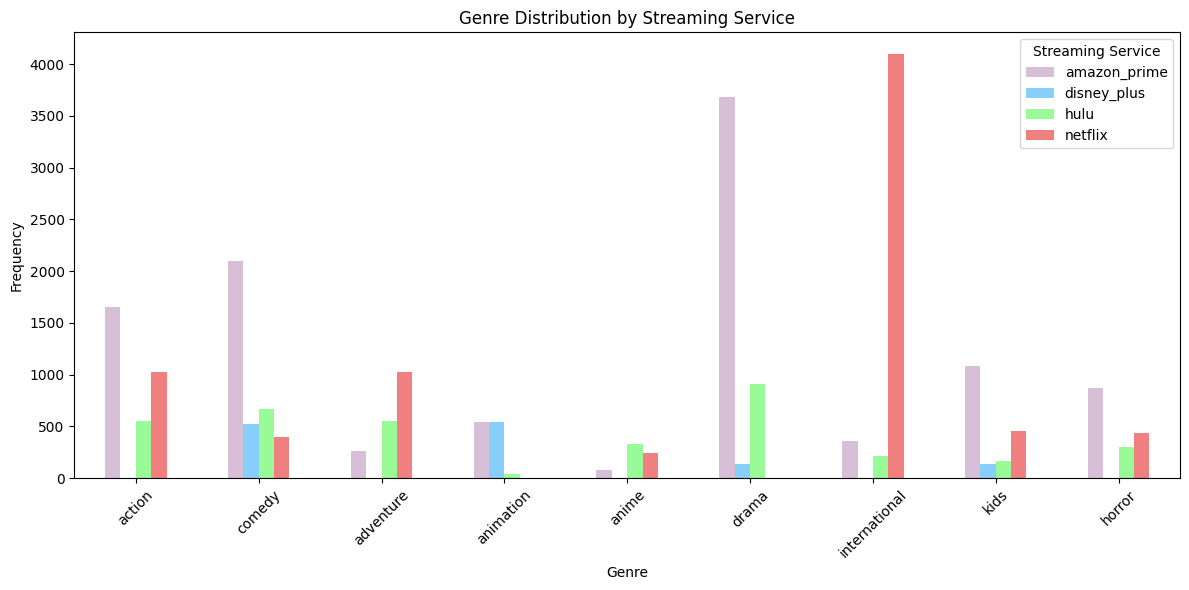

In [ ]:
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

#frequency of each genre for each streaming service
genre_table = streaming_full.groupby("channel_streaming")[genres].sum()
genre_df = pd.DataFrame(genre_table)
genre_df = genre_df.T

#create grouped bar chart of genre by streaming service 
genre_df.plot(kind="bar", figsize=(12, 6), color = ["thistle", "lightskyblue", "palegreen", "lightcoral"])
plt.xlabel("Genre")
plt.ylabel("Frequency")
plt.title("Genre Distribution by Streaming Service")
plt.legend(title="Streaming Service")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** The grouped bar chart indicates that Disney Plus doesn't have any obervations for action, adventure, anime, international, nor horror genres. Similarly, Netflix doesn't have any observations for the animation nor drama genres. Both Amazon Prime and Hulu have observations for each genre. There are two clear frequency outliers, which are Amazon Prime in the drama genre and Netflix in the international genre. Both of those bars have unusually high frequency counts.

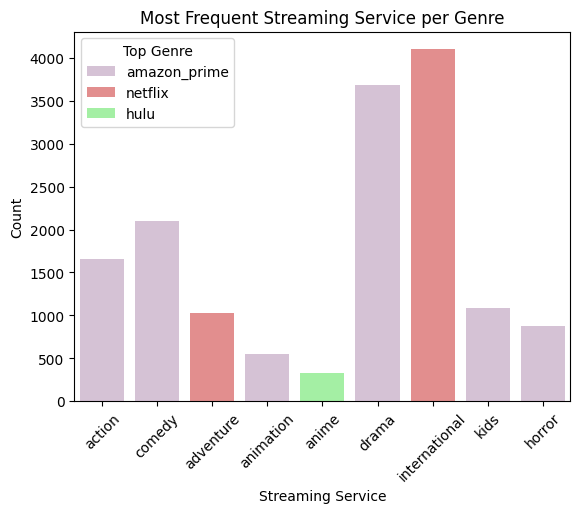

In [ ]:
#max frequency of streaming serivce and max genre
top_genres = genre_df.idxmax(axis=1)
top_counts = genre_df.max(axis=1)

#subset data to streaming services with the highest frequency per genre
top_df = pd.DataFrame({
    "Streaming Service": top_genres.index,
    "Top Genre": top_genres.values,
    "Count": top_counts.values})

#create color pallete to match other graphs
palette = {
    "disney_plus": "lightskyblue",
    "hulu": "palegreen", 
    "amazon_prime": "thistle",
    "netflix": "lightcoral"}

#create bar chart of Most Frequent Streaming Service per Genre
sns.barplot(
    data=top_df,
    x="Streaming Service",
    y="Count",
    hue="Top Genre", 
    palette = palette)

plt.title("Most Frequent Streaming Service per Genre")
plt.xticks(rotation=45)
plt.show()

**Interpretation:** Amazon Prime is the streaming service with the highest frequency in six og the genres (action, comedy, animation, drama, kids, and horror). Netflix has the highest frequency for the adventure and international genres. Hulu has the highest frequency for anime. Disney Plus doesn't have the highest frequency for any of the genres. 

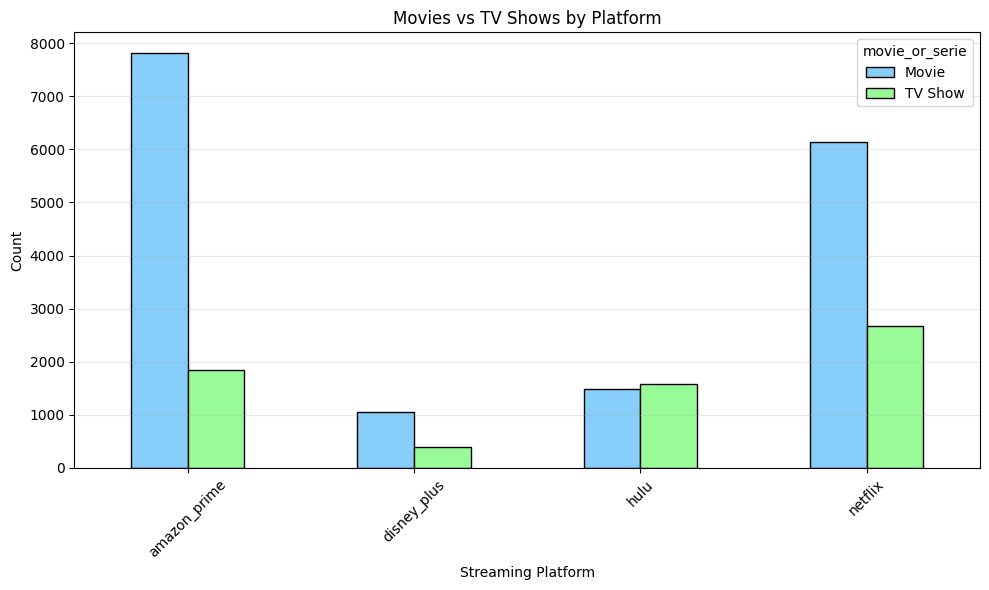

In [38]:
# movies vs tv shows by platform
counts = streaming_full.groupby(["channel_streaming", "movie_or_serie"]).size().unstack()
ax = counts.plot(kind="bar", figsize=(10,6), color=["lightskyblue", "palegreen"], edgecolor='black')
plt.xlabel("Streaming Platform")
plt.ylabel("Count")
plt.title("Movies vs TV Shows by Platform")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**: Amazon Prime, Disney+, and Netflix all have more movies than TV shows. They each have more than two times the number of movies than TV shows. Hulu is the only streaming service with more TV shows than movies. 

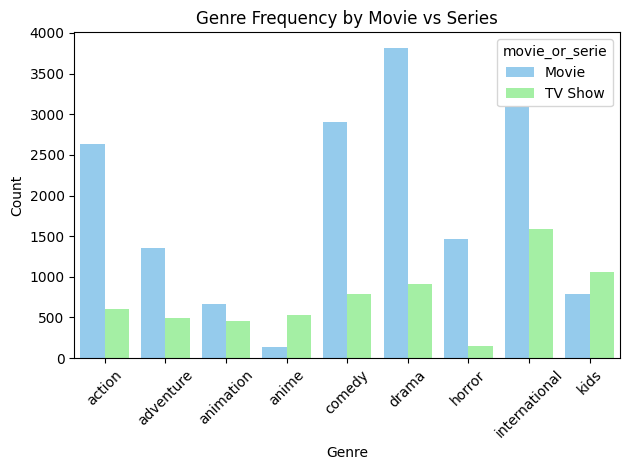

In [ ]:
#format data to long format
long_df = streaming_full.melt(
    id_vars=["movie_or_serie"],
    value_vars=genres,
    var_name="Genre",
    value_name="Has_Genre")

#subset only observations that are 1 (binary variables)
long_df = long_df[long_df["Has_Genre"] == 1]

#create df of frequencies
count_df = (
    long_df
    .groupby(["Genre", "movie_or_serie"])
    .size()
    .reset_index(name="Count"))

#create color pallete to match other graphs
palette = {
    "Movie": "lightskyblue",
    "TV Show": "palegreen"}

#create grouped bar chart of movie or series by genre
sns.barplot(
    data=count_df,
    x="Genre",
    y="Count",
    hue="movie_or_serie",
    palette=palette)

plt.xticks(rotation=45)
plt.title("Genre Frequency by Movie vs Series")
plt.tight_layout()
plt.show()

**Interpretation**: The anime and kids genres have more TV shows than movies. All the other genres have more movies than TV shows. 

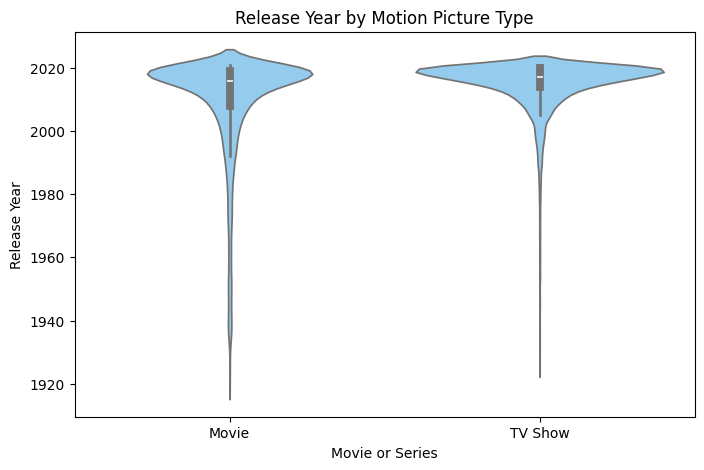

Group means:
movie_or_serie
Movie      2009.224562
TV Show    2014.823845
Name: release_year, dtype: float64


In [73]:
#Side by side violin  plots for release year
plt.figure(figsize=(8, 5))
sns.violinplot(data=streaming_full, x='movie_or_serie', y='release_year', color="lightskyblue")
plt.title('Release Year by Motion Picture Type')
plt.ylabel('Release Year')
plt.xlabel("Movie or Series")
plt.show()

#average release year for movies vs series
means = streaming_full.groupby('movie_or_serie')['release_year'].mean()
print("Group means:")
print(means)

**Interpretation**: The distribution of release year is similar for both movies and series. They are both left skewed. Movies have a more variable spread with a range of 1920-2021 and a mean release date of 2009. TV shows have a slightly smaller range from 1925-2021, with the majority of the observations having a more recent release year, the average being 2015.

### **Documentation**

The first research question explores the relationship between genre and streaming platform. Thus, we created a grouped bar chart of genre distribution by streaming service to visualize the frequencies of each streaming service for each genre. Then, we explored which streaming services had the highest frequency for each of the genres using a bar chart. These graphs allowed us to infer that there appears to be a relationship between genre and streaming platform due to the uneven distributions. The second research question explored the relationship between streaming services and movies or series. So, we created a grouped bar chart with the frequencies of movies and TV shows for each streaming service. This allowed us to visualize the distribution of movie or series across the different platforms. From our graphs we determined that there appears to be a relationship between movie or series and streaming platform due to the unequal distributions. The third research question explores how movies and series are related to the other variables in the dataset. Consequently, we created a grouped bar chart to show the distribution of movie or series for each of the genres in the dataset. Finally, we created side-by-side violin plots to depict the distribution of movie or series by release year. Similarly, we determined that movies and TV shows seem to have unique identifers due to the unequal distributions across the different platform and genres.

### **Reporting and Interpretation**

done throughout the section 

## **Comparative Analysis**

In [ ]:
#NOTE: originally I created these for the descriptive stats, but I think they fit better in this section, feel free to use them if you want here
#frequency of each genre for each streaming service
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

genre_table = streaming_full.groupby("channel_streaming")[genres].sum()

print("Genre Frequency per Streaming Service:")
print(genre_table)

#frequency of each movie or tv show for each streaming service
print("\nMovie or Streaming distributiton for Streaming Service:")
proportions_movie_show = (streaming_full.groupby("channel_streaming")["movie_or_serie"].value_counts(normalize=True).unstack(fill_value=0))
print(proportions_movie_show)

Genre Frequency per Streaming Service:
                   action  comedy  adventure  animation  anime  drama  \
channel_streaming                                                       
amazon_prime         1657    2099        259        547     80   3687   
disney_plus             0     526          0        542      4    134   
hulu                  555     667        556         37    329    907   
netflix              1027     399       1027          0    247      0   

                   international  kids  horror  
channel_streaming                               
amazon_prime                 355  1085     875  
disney_plus                    0   141       0  
hulu                         216   162     304  
netflix                     4103   451     432  

Movie or Streaming distributiton for Streaming Service:
movie_or_serie        Movie   TV Show
channel_streaming                    
amazon_prime       0.808233  0.191767
disney_plus        0.725517  0.274483
hulu               

### **Documentation**

### **Reporting and Interpretation**

## **Multivariate Analysis**

### **Documentation**

### **Reporting and Interpretation**

## **Synthesis**

### **Documentation**

### **Reporting and Interpretation**

## **Reflection**

### **Documentation**

### **Reporting and Interpretation**